<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/NN_baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# Data manipulation
import pandas as pd
import numpy as np
import os
import pickle

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import MinMaxScaler

# Machine Learning metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.models import save_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.metrics import Precision, Recall, AUC

In [3]:
# Path to your saved splits
project_path = '/content/drive/MyDrive/NN_Model/Data_Splits/'

# Load train/test splits
with open(project_path + 'X_train.pkl', 'rb') as f:
    X_train = pickle.load(f)

with open(project_path + 'X_test.pkl', 'rb') as f:
    X_test = pickle.load(f)

with open(project_path + 'y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)

with open(project_path + 'y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

print("Data loaded successfully!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Data loaded successfully!
X_train shape: (5634, 17)
X_test shape: (1409, 17)


In [5]:
# Simple Baseline Neural Network model
baseline_model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1, activation='sigmoid')
])

# Compile Model
baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall(), AUC(name='auc')]
)

# Train model
history = baseline_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6154 - auc: 0.5687 - loss: 0.6536 - precision: 0.2204 - recall: 0.1988 - val_accuracy: 0.7524 - val_auc: 0.7933 - val_loss: 0.4850 - val_precision: 0.6905 - val_recall: 0.0983
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7694 - auc: 0.8191 - loss: 0.4647 - precision: 0.7108 - recall: 0.2246 - val_accuracy: 0.7782 - val_auc: 0.8037 - val_loss: 0.4578 - val_precision: 0.6178 - val_recall: 0.4000
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7860 - auc: 0.8289 - loss: 0.4406 - precision: 0.6599 - recall: 0.4251 - val_accuracy: 0.7799 - val_auc: 0.8081 - val_loss: 0.4528 - val_precision: 0.6063 - val_recall: 0.4542
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7949 - auc: 0.8381 - loss: 0.4245 - precision: 0.6536 - recall: 0.4597 - val_accuracy: 0.7853 - val_auc: 0.8107 - val_loss: 0.4511 - val_precision: 0.6064 - val_recall: 0.5119
Epoch 5/20
141/141 ━━━━━━━━━━━━━

177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

TRAIN METRICS
Train Accuracy: 0.802626908058218
Train Precision: 0.6428038777032066
Train Recall: 0.5765886287625418
Train F1 Score: 0.607898448519041

TEST METRICS
Test Accuracy: 0.7970191625266146
Test Precision: 0.6286549707602339
Test Recall: 0.5748663101604278
Test F1 Score: 0.6005586592178771

--------TRAINING SET REPORT--------
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      4139
           1       0.64      0.58      0.61      1495

    accuracy                           0.80      5634
   macro avg       0.75      0.73      0.74      5634
weighted avg       0.80      0.80      0.80      5634


--------TEST SET REPORT--------
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1035
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   

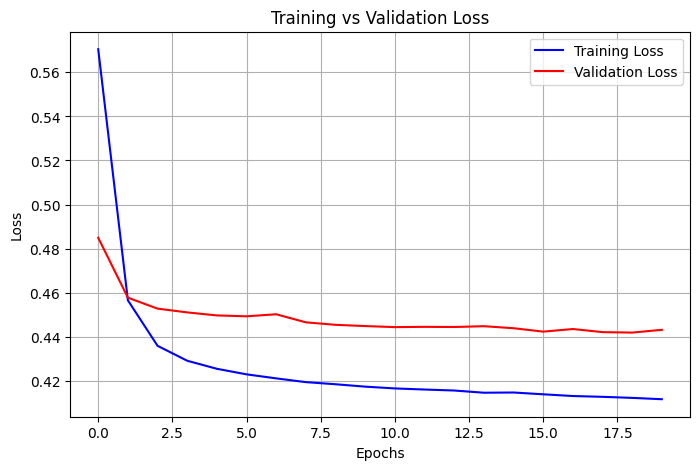

In [6]:
# Predict using default threshold (0.5)
y_train_pred = (baseline_model.predict(X_train) > 0.5).astype(int)
y_test_pred  = (baseline_model.predict(X_test)  > 0.5).astype(int)

# Train Metrics
print("\nTRAIN METRICS")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Train Precision:", precision_score(y_train, y_train_pred))
print("Train Recall:", recall_score(y_train, y_train_pred))
print("Train F1 Score:", f1_score(y_train, y_train_pred))

# Test Metrics
print("\nTEST METRICS")
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test F1 Score:", f1_score(y_test, y_test_pred))

# Classification Reports
print("\n--------TRAINING SET REPORT--------")
print(classification_report(y_train, y_train_pred))

print("\n--------TEST SET REPORT--------")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("\n--------Confusion Matrix (Test):\n", cm)

# Loss Plot
try:
    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'],     'b-', label='Training Loss')
    plt.plot(history.history['val_loss'], 'r-', label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
except:
    print("No training history available for loss plot.")


In [7]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 917 (3.59 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 612 (2.39 KB)

In [ ]:
# Create folder to save all baseline artifacts
baseline_path = '/content/drive/MyDrive/NN_Model/Baseline_Model/'
os.makedirs(baseline_path, exist_ok=True)

# Save the trained Keras model
baseline_model.save(os.path.join(baseline_path, 'baseline_model.h5'))

# Save predictions
with open(os.path.join(baseline_path, 'y_train_pred.pkl'), 'wb') as f:
    pickle.dump(y_train_pred, f)

with open(os.path.join(baseline_path, 'y_test_pred.pkl'), 'wb') as f:
    pickle.dump(y_test_pred, f)

# Save evaluation metrics
metrics = {
    'train_accuracy': accuracy_score(y_train, y_train_pred),
    'train_precision': precision_score(y_train, y_train_pred),
    'train_recall': recall_score(y_train, y_train_pred),
    'train_f1': f1_score(y_train, y_train_pred),

    'test_accuracy': accuracy_score(y_test, y_test_pred),
    'test_precision': precision_score(y_test, y_test_pred),
    'test_recall': recall_score(y_test, y_test_pred),
    'test_f1': f1_score(y_test, y_test_pred),

    'confusion_matrix': confusion_matrix(y_test, y_test_pred)
}

with open(os.path.join(baseline_path, 'baseline_metrics.pkl'), 'wb') as f:
    pickle.dump(metrics, f)

# Save training history
with open(os.path.join(baseline_path, 'history.pkl'), 'wb') as f:
    pickle.dump(history.history, f)

print("Baseline model, predictions, metrics, and history saved successfully!")


Model saved to Google Drive at: /content/drive/MyDrive/NN_baseline_model.h5


Baseline Neural Network Model – Summary

Model Architecture

*   Input Layer: Size = number of features (X_train.shape[1])
*   Hidden Layers:
      Dense(16, activation='relu')
*   Output Layer: Dense(1, activation='sigmoid')

Performance on Training Set

    Accuracy: 80.3%

    Precision: 64.3%

    Recall: 57.7%

    F1-score: 0.608

Performance on Test Set

    Accuracy: 79.7%

    Precision: 62.9%

    Recall: 57.5%

    F1-score: 0.601

Confusion Matrix (Test):

[[908 127]
 [159 215]]


Observations

Accuracy is reasonably high, but recall for the minority class (Churn = 1) is moderate, indicating some missed churners.

Class imbalance (roughly 3:1 for non-churn:churn) is likely causing the model to favor the majority class.

F1-score shows there’s room to balance precision and recall better.

Next Steps

Address class imbalance using class weights, oversampling (SMOTE), or undersampling.

Adjust the classification threshold to improve recall and F1-score.

Tune hyperparameters (epochs, batch size, learning rate, dropout) after handling imbalance.
